# Limpeza e Análise de Dados de Vendas


In [2]:
import pandas as pd

In [ ]:
# Importando a base
vendas = pd.read_csv('data_raw.csv')

In [ ]:
# Visualizar até 100 linhas
pd.set_option('display.max_rows', 100)

In [ ]:
vendas.head()

,ID,Data,Produto,Categoria,Quantidade,Preço
0,1,2023-11-24,Teclado Mecânico,Periféricos,1.0,333.93
1,2,2023-02-22,Cabo HDMI,Acessórios,5.0,16.11
2,3,2023-02-17,Smartphone Samsung Galaxy,Celulares,1.0,2210.24
3,4,2023-11-29,Caixa de Som JBL,Áudio,2.0,553.56
4,5,2023-01-04,Webcam Full HD,Periféricos,2.0,235.06


## Análise de Inconsistências

In [ ]:
vendas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 309 entries, 0 to 308
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   ID          309 non-null    int64  
 1   Data        309 non-null    object 
 2   Produto     309 non-null    object 
 3   Categoria   304 non-null    object 
 4   Quantidade  304 non-null    float64
 5   Preço       304 non-null    float64
dtypes: float64(2), int64(1), object(3)
memory usage: 14.6+ KB


A verificação inicial de dados faltantes df.info() revelou a presença de missing values (dados faltantes) em algumas colunas:
`Quantidade`, `Categoria` e `Preço` (5 em cada)
As variáveis `ID`, `Data`, `Produto` estão completas. Os tipos de dados estao adequados, com as variáveis numéricas sendo do tipo float, o ID sendo int e as categóricas do tipo object.

In [ ]:
vendas.describe()

,ID,Quantidade,Preço
count,309.000000,304.000000,304.000000
mean,155.000000,2.562500,815.101821
std,89.344838,1.348282,1201.858559
min,1.000000,1.000000,15.330000
25%,78.000000,2.000000,68.502500
50%,155.000000,2.000000,304.485000
75%,232.000000,3.000000,949.497500
max,309.000000,10.000000,5757.440000


* Dados Faltantes:
  * A contagem count confirma a presença de dados faltantes, como identificado anteriormente.

In [ ]:
# Procurando por linhas identicas
duplicadas = vendas[vendas.duplicated(keep=False)]

print(f"Total de linhas duplicadas: {len(duplicadas)}")
print("Prévia das duplicatas encontradas:")
duplicadas.head()

Total de linhas duplicadas: 0
Prévia das duplicatas encontradas:


,ID,Data,Produto,Categoria,Quantidade,Preço


In [ ]:
# Procurando por Dados identicos (sem considerar o ID)
colunas_sem_id = [col for col in vendas.columns if col != 'ID']

# Encontra linhas duplicadas com base nessas colunas
duplicadas = vendas[vendas.duplicated(subset=colunas_sem_id, keep=False)]

print(f"Total de linhas duplicadas (ignorando 'ID'): {len(duplicadas)}")
duplicadas.sort_values(by=colunas_sem_id).head()

Total de linhas duplicadas (ignorando 'ID'): 18


,ID,Data,Produto,Categoria,Quantidade,Preço
184,185,2023-01-15,Mouse Logitech,Periféricos,2.0,140.94
301,302,2023-01-15,Mouse Logitech,Periféricos,2.0,140.94
268,269,2023-02-09,Cabo HDMI,Acessórios,5.0,31.19
300,301,2023-02-09,Cabo HDMI,Acessórios,5.0,31.19
10,11,2023-02-21,Fones Bluetooth,Áudio,2.0,165.06


In [ ]:
df_limpo = vendas.drop_duplicates(subset=colunas_sem_id, keep='first')

In [ ]:
df_limpo.info()

<class 'pandas.core.frame.DataFrame'>
Index: 300 entries, 0 to 299
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   ID          300 non-null    int64  
 1   Data        300 non-null    object 
 2   Produto     300 non-null    object 
 3   Categoria   295 non-null    object 
 4   Quantidade  295 non-null    float64
 5   Preço       295 non-null    float64
dtypes: float64(2), int64(1), object(3)
memory usage: 16.4+ KB


* Após a remoção das duplicatas, a base ficou com 300 observações

In [ ]:
# Tratando valores faltantes de Categoria
# É possível analisar o conjunto dos pares dos produtos para tentar mapear o produto para uma categoria ja conhecida, caso não for mapeado ele será datado como "Outro"

def busca_categoria(df, produto):
  'Busca no df a categoria do produto não nula'
  filtro = (df['Produto'] == produto) & (df['Categoria'].notnull())
  if not df.loc[filtro, 'Categoria'].empty:
      return df.loc[filtro, 'Categoria'].iloc[0]
  else:
      return "Outro"

for idx in df_limpo[df_limpo['Categoria'].isnull()].index:
            produto = df_limpo.loc[idx, 'Produto']
            df_limpo.loc[idx, 'Categoria'] = busca_categoria(df_limpo, produto)



In [ ]:
# Tratando valores faltantes de Quantidade e Preço: imputar com mediana por produto
# Preenchendo valores faltantes com a mediana por produto para não perder informações e manter valores realistas para quantidade e preço

df_limpo.loc[:, 'Quantidade'] = df_limpo.groupby('Produto')['Quantidade'].transform(
    lambda x: x.fillna(x.median())
)
df_limpo.loc[:, 'Preço'] = df_limpo.groupby('Produto')['Preço'].transform(
    lambda x: x.fillna(x.median())
)


In [ ]:
df_limpo.head()

,ID,Data,Produto,Categoria,Quantidade,Preço
0,1,2023-11-24,Teclado Mecânico,Periféricos,1.0,333.93
1,2,2023-02-22,Cabo HDMI,Acessórios,5.0,16.11
2,3,2023-02-17,Smartphone Samsung Galaxy,Celulares,1.0,2210.24
3,4,2023-11-29,Caixa de Som JBL,Áudio,2.0,553.56
4,5,2023-01-04,Webcam Full HD,Periféricos,2.0,235.06


In [ ]:
df_limpo.info()

<class 'pandas.core.frame.DataFrame'>
Index: 300 entries, 0 to 299
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   ID          300 non-null    int64  
 1   Data        300 non-null    object 
 2   Produto     300 non-null    object 
 3   Categoria   300 non-null    object 
 4   Quantidade  300 non-null    float64
 5   Preço       300 non-null    float64
dtypes: float64(2), int64(1), object(3)
memory usage: 24.5+ KB


In [ ]:
# Procurando Outliers

def buscar_outliers(df, col, factor=1.5):
    """
    Identifica outliers em uma coluna numérica via IQR

    Parâmetros:
        df (pd.DataFrame): DataFrame a ser analisado
        col (str): nome da coluna
        factor (float): fator multiplicador do IQR (apenas para método IQR)

    Retorna:
        pd.Series de booleanos indicando True para outliers
    """
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_sup = Q3 + factor * IQR
    limite_inf = Q1 - factor * IQR
    outliers = (df[col] < limite_inf) | (df[col] > limite_sup)
    return outliers

# Cria subset para Preço e Quantidade
subset = df_limpo[['Quantidade', 'Preço']]

outliers_preco = buscar_outliers(subset, 'Preço')
outliers_quantidade = buscar_outliers(subset, 'Quantidade')
print(f"Total de outliers em Preço: {outliers_preco.sum()}")
print(f"Total de outliers em Quantidade: {outliers_quantidade.sum()}")

Total de outliers em Preço: 39
Total de outliers em Quantidade: 30


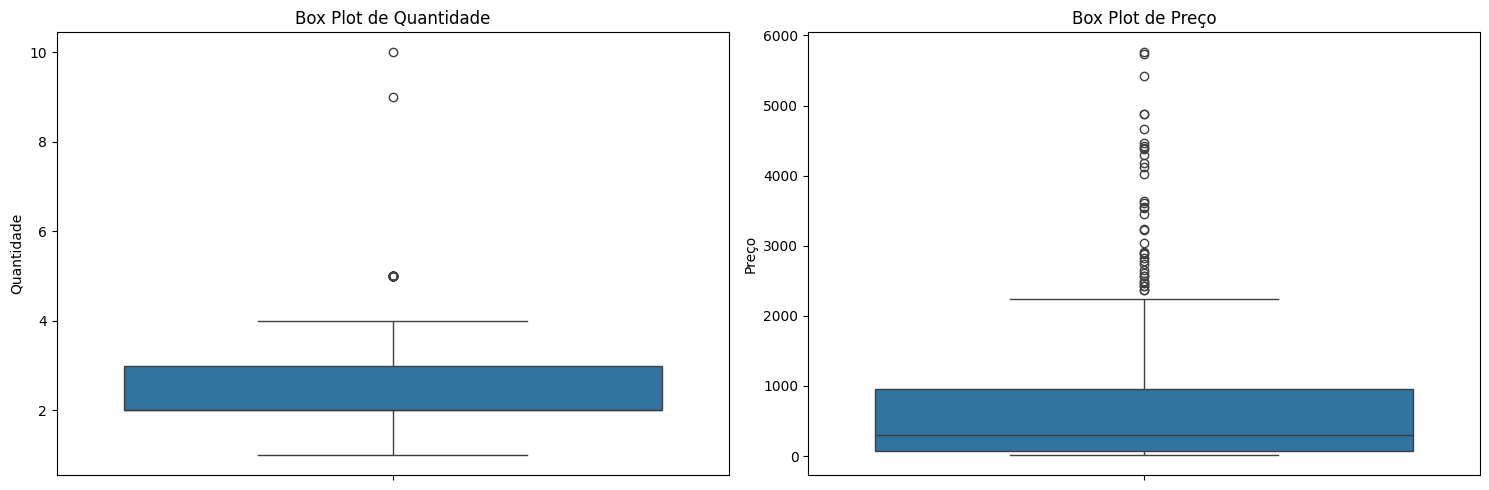

In [ ]:
# Visualizando em BoxPlot a distribuição de Quantidade e Preço
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.boxplot(ax=axes[0], y=df_limpo['Quantidade'])
axes[0].set_title('Box Plot de Quantidade')
axes[0].set_ylabel('Quantidade')

sns.boxplot(ax=axes[1], y=df_limpo['Preço'])
axes[1].set_title('Box Plot de Preço')
axes[1].set_ylabel('Preço')

plt.tight_layout()
plt.show()

* Observações
  * Acerca de quantidade, considerando valores reais, é aceitável valores acima do limiar de 4, que não ultrapassam o valor de 10 no quesito de vendas.
  * Vale-se observar os casos de preço a fim de entender se são factuais ou não.

In [ ]:
# Visualizando quem são os outliers
print("Quantidade Total:" + str(len(df_limpo[outliers_preco | outliers_quantidade])))
df_limpo[outliers_preco | outliers_quantidade]

Quantidade Total:65


,ID,Data,Produto,Categoria,Quantidade,Preço
1,2,2023-02-22,Cabo HDMI,Acessórios,5.0,16.110000
6,7,2023-02-19,Tablet iPad,Tablets,2.0,3614.260000
7,8,2023-08-24,HD Externo 1TB,Armazenamento,5.0,548.820000
11,12,2023-07-01,Smartphone Samsung Galaxy,Celulares,3.0,2366.460000
13,14,2023-07-14,Smartphone Samsung Galaxy,Celulares,4.0,2432.310000
15,16,2023-02-03,Smartphone Samsung Galaxy,Celulares,5.0,1582.730000
16,17,2023-09-13,Fones Bluetooth,Áudio,5.0,155.850000
18,19,2023-07-24,Tablet iPad,Tablets,5.0,2181.820000
21,22,2023-09-28,Smartphone Samsung Galaxy,Celulares,1.0,2424.510000
25,26,2023-11-17,iPhone 14,Celulares,3.0,4397.820000


* Acerca dos preços existe uma variação grande pela prórpia natureza dos tipos de produto, logo, essa analise de outliers deve ser feita sob os grupos de cada produto

In [ ]:
# Procurando outliers por produto

outliers_por_produto = {}

for produto in df_limpo['Produto'].unique():
    df_produto = df_limpo[df_limpo['Produto'] == produto].copy()
    outliers_preco_produto = buscar_outliers(df_produto, 'Preço')
    outliers_quantidade_produto = buscar_outliers(df_produto, 'Quantidade')

    if outliers_preco_produto.sum() > 0 or outliers_quantidade_produto.sum() > 0:
        outliers_por_produto[produto] = df_produto[outliers_preco_produto | outliers_quantidade_produto]

print("Outliers por Produto:")
for produto, outliers_df in outliers_por_produto.items():
    print(f"\nProduto: {produto}")
    display(outliers_df)

Outliers por Produto:

Produto: Teclado Mecânico


,ID,Data,Produto,Categoria,Quantidade,Preço
149,150,2023-11-28,Teclado Mecânico,Periféricos,1.0,1441.695917



Produto: Cabo HDMI


,ID,Data,Produto,Categoria,Quantidade,Preço
1,2,2023-02-22,Cabo HDMI,Acessórios,5.0,16.11
30,31,2023-03-07,Cabo HDMI,Acessórios,5.0,48.75
197,198,2023-03-12,Cabo HDMI,Acessórios,5.0,42.60
212,213,2023-08-01,Cabo HDMI,Acessórios,5.0,16.15
268,269,2023-02-09,Cabo HDMI,Acessórios,5.0,31.19
277,278,2023-10-26,Cabo HDMI,Acessórios,5.0,19.51



Produto: Caixa de Som JBL


...

,ID,Data,Produto,Categoria,Quantidade,Preço
203,204,2023-12-12,Cadeira Gamer,Móveis,5.0,953.51



Produto: Mouse Logitech


,ID,Data,Produto,Categoria,Quantidade,Preço
263,264,2023-12-02,Mouse Logitech,Periféricos,5.0,208.26



Produto: SSD 512GB


,ID,Data,Produto,Categoria,Quantidade,Preço
123,124,2023-08-26,SSD 512GB,Armazenamento,2.0,2783.28372


* A partir dos dados acima é possível realizar um comparativo com preços reais a fim de entender se os dados estão dentro do esperado.
Partindo de um conjunto de dados exemplo:




In [ ]:
# @title
from IPython.display import display, HTML

display(HTML("""
<table>
<tr><th>Nome do produto</th><th>Preço de mercado (R$)</th></tr>
<tr><td><b>Cabo HDMI</b></td><td>R$ 15 – R$ 50</td></tr>
<tr><td><b>Pen Drive 64GB</b></td><td>R$ 25 – R$ 80</td></tr>
<tr><td><b>Carregador USB-C</b></td><td>R$ 30 – R$ 80</td></tr>
<tr><td><b>Mouse Logitech</b></td><td>R$ 80 – R$ 250</td></tr>
<tr><td><b>Mousepad Gamer</b></td><td>R$ 50 – R$ 200</td></tr>
<tr><td><b>Fones Bluetooth</b></td><td>R$ 100 – R$ 500</td></tr>
<tr><td><b>Webcam Full HD</b></td><td>R$ 150 – R$ 400</td></tr>
<tr><td><b>Roteador Wi-Fi</b></td><td>R$ 150 – R$ 500</td></tr>
<tr><td><b>Teclado Mecânico</b></td><td>R$ 200 – R$ 800</td></tr>
<tr><td><b>Caixa de Som JBL</b></td><td>R$ 200 – R$ 800</td></tr>
<tr><td><b>HD Externo 1TB</b></td><td>R$ 300 – R$ 600</td></tr>
<tr><td><b>SSD 512GB</b></td><td>R$ 400 – R$ 800</td></tr>
<tr><td><b>Impressora HP</b></td><td>R$ 400 – R$ 1.200</td></tr>
<tr><td><b>Mesa de Escritório</b></td><td>R$ 600 – R$ 1.800</td></tr>
<tr><td><b>Monitor Samsung 24"</b></td><td>R$ 800 – R$ 1.500</td></tr>
<tr><td><b>Cadeira Gamer</b></td><td>R$ 800 – R$ 2.500</td></tr>
<tr><td><b>Smartphone Samsung Galaxy</b></td><td>R$ 1.200 – R$ 3.000</td></tr>
<tr><td><b>Tablet iPad</b></td><td>R$ 2.000 – R$ 4.000</td></tr>
<tr><td><b>Notebook Dell Inspiron</b></td><td>R$ 2.500 – R$ 4.500</td></tr>
<tr><td><b>iPhone 14</b></td><td>R$ 4.000 – R$ 6.000</td></tr>
</table>
"""))


Nome do produto,Preço de mercado (R$)
Cabo HDMI,R$ 15 – R$ 50
Pen Drive 64GB,R$ 25 – R$ 80
Carregador USB-C,R$ 30 – R$ 80
Mouse Logitech,R$ 80 – R$ 250
Mousepad Gamer,R$ 50 – R$ 200
Fones Bluetooth,R$ 100 – R$ 500
Webcam Full HD,R$ 150 – R$ 400
Roteador Wi-Fi,R$ 150 – R$ 500
Teclado Mecânico,R$ 200 – R$ 800
Caixa de Som JBL,R$ 200 – R$ 800


Os produtos que foram identificados fora do range padrão do mercado foram:
* O Teclado de ID 150 com o valor de RS 1441.70 que ultrapassa o maior valor identificado na tabela que é de 800 reais;
* A WebCam de ID 220 com o valor de RS 3041.16 que ultrapassa o padrão de 400 reais máximo.
* Os MousePads Gamer de IDs 74 e 295 com valores de RS 992.74 e RS 627.48, respectivamente, que são maiores que o valor máximo de 200 reais identificado na tabela.
* O SSD de ID 124 com o preço de RS 2783.28, mas o padrão limite é de 800 reais.


**DECISÃO PARA TRATAMENTO DE OUTLIERS DE PREÇO**

Considerando que a variável de preço constitui uma métrica fundamental para as análises em curso, e diante da identificação de 5 registros que apresentam valores significativamente discrepantes em relação aos parâmetros estabelecidos pelo mercado, foi determinada a seguinte ação:

**Procedimento:**
**Exclusão dos registros inconsistentes** da base de dados analítica.

**Fundamentação:**
1. **Representatividade Limitada:** Os casos identificados representam apenas 1,6% do total da base, não comprometendo a significância estatística do conjunto
2. **Magnitude da Discrepância:** Os valores excedem em mais de 80% os limites superiores estabelecidos, caracterizando anomalias evidentes
3. **Integridade Analítica:** A manutenção desses outliers distorceria substancialmente os resultados de modelos estatísticos e análises de tendência

**Salvaguarda:**
Os registros excluídos serão arquivados em base separada para eventual auditoria futura, mantendo a rastreabilidade das decisões tomadas.

Esta medida visa assegurar a confiabilidade dos insights gerados a partir da base de dados, preservando a qualidade e consistência das análises subsequentes.

In [ ]:
# Separar em uma base especifica os IDs 150, 220, 74, 295 e 124
outliers_ids = [150, 220, 74, 295, 124]
outliers_df = df_limpo[df_limpo['ID'].isin(outliers_ids)]
outliers_df.to_csv('outliers.csv', index=False)

In [ ]:
# Remover os outliers da base
df_limpo = df_limpo[~df_limpo['ID'].isin(outliers_ids)]

In [ ]:
# identificando algum valor que é decimal em quantidade
df_limpo[df_limpo['Quantidade'] % 1 != 0]

,ID,Data,Produto,Categoria,Quantidade,Preço
120,122,2023-10-03,Webcam Full HD,Periféricos,2.5,298.12
213,217,2023-04-19,Cabo HDMI,Acessórios,2.5,16.77


In [ ]:
# Arredondando valores de quantidade não inteiros
df_limpo['Quantidade'] = df_limpo['Quantidade'].round()

In [ ]:
df_limpo.info()

<class 'pandas.core.frame.DataFrame'>
Index: 295 entries, 0 to 299
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   ID          295 non-null    int64  
 1   Data        295 non-null    object 
 2   Produto     295 non-null    object 
 3   Categoria   295 non-null    object 
 4   Quantidade  295 non-null    float64
 5   Preço       295 non-null    float64
dtypes: float64(2), int64(1), object(3)
memory usage: 16.1+ KB


In [ ]:
df_limpo.to_csv('df_limpo.csv', index=False)

## Análise de Vendas

In [ ]:
vendas = pd.read_csv('df_limpo.csv')

In [ ]:
# Calcular vendas totais por produto
vendas_totais = vendas.groupby('Produto')['Quantidade'].sum()

In [ ]:
vendas_totais

,Quantidade
Produto,
Cabo HDMI,98.0
Cadeira Gamer,13.0
Caixa de Som JBL,35.0
Carregador USB-C,73.0
Fones Bluetooth,40.0
HD Externo 1TB,22.0
Impressora HP,5.0
Mesa de Escritório,7.0
"Monitor Samsung 24""",22.0


In [ ]:
# Vendas totais de todos os produtos
print(vendas['Quantidade'].sum())

754.0


In [ ]:
# Analisando o valor obtido por cada venda
vendas['Valor'] = vendas['Quantidade'] * vendas['Preço']

In [ ]:
# 1. Total de vendas por produto
vendas_por_produto = vendas.groupby('Produto').agg({
            'Valor': 'sum',
            'Quantidade': 'sum',
            'ID': 'count'
        }).rename(columns={'ID': 'Num_Transações'}).sort_values('Valor', ascending=False)

In [ ]:
# 2. Produto com maior número de vendas
produto_top = vendas_por_produto.index[0]
valor_top = vendas_por_produto.loc[produto_top, 'Valor']

In [ ]:
# 3. Análise por categoria
vendas_por_categoria = vendas.groupby('Categoria').agg({
    'Valor': 'sum',
    'Quantidade': 'sum',
    'ID': 'count'
}).rename(columns={'ID': 'Num_Transações'}).sort_values('Valor', ascending=False)

In [ ]:
resultados = {
            'vendas_por_produto': vendas_por_produto,
            'vendas_por_categoria': vendas_por_categoria,
            'produto_lider': produto_top,
            'valor_lider': valor_top,
            'total_geral': vendas['Valor'].sum()
        }

In [ ]:
resultados

{'vendas_por_produto':                                 Valor  Quantidade  Num_Transações
 Produto                                                          
 iPhone 14                  170895.920        37.0              14
 Smartphone Samsung Galaxy  149106.720        73.0              30
 Tablet iPad                105616.380        36.0              10
 Notebook Dell Inspiron      26484.380         8.0               3
 Monitor Samsung 24"         24309.810        22.0               8
 Caixa de Som JBL            22576.750        35.0              12
 Cadeira Gamer               19324.350        13.0               5
 SSD 512GB                   16066.330        30.0              12
 Teclado Mecânico            15966.970        29.0              15
 Webcam Full HD              14043.360        48.0              18
 Fones Bluetooth             11887.420        40.0              17
 HD Externo 1TB              11828.090        22.0               9
 Mouse Logitech               8464.590  

In [ ]:
resultados['vendas_por_produto'].to_csv('analise_vendas_por_produto.csv')
resultados['vendas_por_categoria'].to_csv('analise_vendas_por_categoria.csv')

In [34]:
vendas.to_csv('vendas_limpo.csv', index=False)

# Análise Exploratória de Dados de Vendas

In [5]:
vendas_limpo = pd.read_csv('/home/carlosnogueira/Documentos/Teste_Analytics_CarlosNogueira/data/processed/vendas_limpo.csv')
analise_categoria = pd.read_csv('/home/carlosnogueira/Documentos/Teste_Analytics_CarlosNogueira/data/analysis_results/analise_vendas_por_categoria.csv')
analise_produto = pd.read_csv('/home/carlosnogueira/Documentos/Teste_Analytics_CarlosNogueira/data/analysis_results/analise_vendas_por_produto.csv')

In [36]:
print(f"Dataset principal - Shape: {vendas_limpo.shape}")
print(f"Análise por categoria - Shape: {analise_categoria.shape}")
print(f"Análise por produto - Shape: {analise_produto.shape}")

Dataset principal - Shape: (295, 7)
Análise por categoria - Shape: (11, 4)
Análise por produto - Shape: (20, 4)


In [37]:
vendas_limpo.head()

,ID,Data,Produto,Categoria,Quantidade,Preço,Valor
0,1,2023-11-24,Teclado Mecânico,Periféricos,1.0,333.93,333.93
1,2,2023-02-22,Cabo HDMI,Acessórios,5.0,16.11,80.55
2,3,2023-02-17,Smartphone Samsung Galaxy,Celulares,1.0,2210.24,2210.24
3,4,2023-11-29,Caixa de Som JBL,Áudio,2.0,553.56,1107.12
4,5,2023-01-04,Webcam Full HD,Periféricos,2.0,235.06,470.12


In [6]:
# Conversão da coluna Data para datetime
vendas_limpo['Data'] = pd.to_datetime(vendas_limpo['Data'])

# Criação de colunas derivadas para análise temporal
vendas_limpo['Ano'] = vendas_limpo['Data'].dt.year
vendas_limpo['Mes'] = vendas_limpo['Data'].dt.month
vendas_limpo['Ano_Mes'] = vendas_limpo['Data'].dt.to_period('M')

In [42]:
print("Range de datas:", vendas_limpo['Data'].min(), "até", vendas_limpo['Data'].max())
print("Total de registros:", len(vendas_limpo))
print("Total de receita:", f"R$ {vendas_limpo['Valor'].sum():,.2f}")

Range de datas: 2023-01-01 00:00:00 até 2023-12-29 00:00:00
Total de registros: 295
Total de receita: R$ 634,427.09


In [43]:
# Verificação das análises existentes
print("\n=== ANÁLISES EXISTENTES ===")
print("\nAnálise por categoria:")
print(analise_categoria)
print("\nAnálise por produto:")
print(analise_produto.head(10))


=== ANÁLISES EXISTENTES ===

Análise por categoria:
        Categoria       Valor  Quantidade  Num_Transações
0       Celulares  320002.640       110.0              44
1         Tablets  105616.380        36.0              10
2     Periféricos   44861.850       181.0              73
3           Áudio   34464.170        75.0              29
4   Armazenamento   30607.845       105.0              44
5          Móveis   27297.820        20.0               8
6    Computadores   26484.380         8.0               3
7       Monitores   24309.810        22.0               8
8            Rede    8292.430        21.0               9
9      Acessórios    7470.570       171.0              65
10    Impressoras    5019.200         5.0               2

Análise por produto:
                     Produto      Valor  Quantidade  Num_Transações
0                  iPhone 14  170895.92        37.0              14
1  Smartphone Samsung Galaxy  149106.72        73.0              30
2                Tablet i

In [44]:
# Resumo estatístico básico
print("\n=== ESTATÍSTICAS DESCRITIVAS ===")
print(vendas_limpo[['Quantidade', 'Preço', 'Valor']].describe())


=== ESTATÍSTICAS DESCRITIVAS ===
       Quantidade        Preço         Valor
count  295.000000   295.000000    295.000000
mean     2.555932   807.364373   2150.600322
std      1.341168  1205.419668   3840.339976
min      1.000000    15.330000     15.330000
25%      2.000000    67.720000    150.880000
50%      2.000000   298.120000    553.310000
75%      3.000000   798.205000   2143.360000
max     10.000000  5757.440000  31849.920000


In [64]:
# Análise temporal mensal
print("=== ANÁLISE TEMPORAL MENSAL ===")

# Agregação mensal dos dados
vendas_mensais = vendas_limpo.groupby('Ano_Mes').agg({
    'Valor': 'sum',
    'Quantidade': 'sum',
    'ID': 'count'  # número de transações
}).reset_index()

vendas_mensais.rename(columns={'ID': 'Num_Transações'}, inplace=True)
vendas_mensais['Ano_Mes_str'] = vendas_mensais['Ano_Mes'].astype(str)

print("Vendas mensais:")
print(vendas_mensais)

=== ANÁLISE TEMPORAL MENSAL ===
Vendas mensais:
    Ano_Mes      Valor  Quantidade  Num_Transações Ano_Mes_str
0   2023-01  38606.080        56.0              27     2023-01
1   2023-02  77691.730        90.0              31     2023-02
2   2023-03  43005.670        51.0              19     2023-03
3   2023-04  58806.690        42.0              16     2023-04
4   2023-05  42521.470        76.0              31     2023-05
5   2023-06  63524.545        65.0              26     2023-06
6   2023-07  99894.020        74.0              25     2023-07
7   2023-08  45679.620        68.0              26     2023-08
8   2023-09  20444.330        28.0              11     2023-09
9   2023-10  41440.870        69.0              28     2023-10
10  2023-11  60319.660        44.0              20     2023-11
11  2023-12  42492.410        91.0              35     2023-12


In [66]:
# Calcular estatísticas mensais
receita_media_mensal = vendas_mensais['Valor'].mean()
mes_maior_receita = vendas_mensais.loc[vendas_mensais['Valor'].idxmax()]
mes_menor_receita = vendas_mensais.loc[vendas_mensais['Valor'].idxmin()]

print(f"\nReceita média mensal: R$ {receita_media_mensal:,.2f}")
print(f"Mês com maior receita: {mes_maior_receita['Ano_Mes']} - R$ {mes_maior_receita['Valor']:,.2f}")
print(f"Mês com menor receita: {mes_menor_receita['Ano_Mes']} - R$ {mes_menor_receita['Valor']:,.2f}")

# Preparar dados para visualizações
# Salvar os dados processados
vendas_mensais.to_csv('vendas_mensais_analise.csv', index=False)
print("\nArquivo 'vendas_mensais_analise.csv' salvo com sucesso!")


Receita média mensal: R$ 52,868.92
Mês com maior receita: 2023-07 - R$ 99,894.02
Mês com menor receita: 2023-09 - R$ 20,444.33

Arquivo 'vendas_mensais_analise.csv' salvo com sucesso!


In [67]:
vendas_mensais.head()

,Ano_Mes,Valor,Quantidade,Num_Transações,Ano_Mes_str
0,2023-01,38606.08,56.0,27,2023-01
1,2023-02,77691.73,90.0,31,2023-02
2,2023-03,43005.67,51.0,19,2023-03
3,2023-04,58806.69,42.0,16,2023-04
4,2023-05,42521.47,76.0,31,2023-05


In [50]:
vendas_limpo.head()

,ID,Data,Produto,Categoria,Quantidade,Preço,Valor,Ano,Mes,Ano_Mes
0,1,2023-11-24,Teclado Mecânico,Periféricos,1.0,333.93,333.93,2023,11,2023-11
1,2,2023-02-22,Cabo HDMI,Acessórios,5.0,16.11,80.55,2023,2,2023-02
2,3,2023-02-17,Smartphone Samsung Galaxy,Celulares,1.0,2210.24,2210.24,2023,2,2023-02
3,4,2023-11-29,Caixa de Som JBL,Áudio,2.0,553.56,1107.12,2023,11,2023-11
4,5,2023-01-04,Webcam Full HD,Periféricos,2.0,235.06,470.12,2023,1,2023-01


In [9]:
import plotly.express as px
import plotly.graph_objects as go
from datetime import datetime
import numpy as np

In [10]:
vendas_mensais = vendas_limpo.groupby('Ano_Mes')['Valor'].sum().reset_index()

nomes_meses = ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun',
               'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez']
vendas_mensais['Mes_Label'] = [nomes_meses[i] for i in range(len(vendas_mensais))]

vendas_mensais['Valor_k'] = vendas_mensais['Valor'] / 1000

print("Dados das Vendas mensais:")
print(vendas_mensais[['Mes_Label', 'Valor', 'Valor_k']])

Dados das Vendas mensais:
   Mes_Label      Valor    Valor_k
0        Jan  38606.080  38.606080
1        Fev  77691.730  77.691730
2        Mar  43005.670  43.005670
3        Abr  58806.690  58.806690
4        Mai  42521.470  42.521470
5        Jun  63524.545  63.524545
6        Jul  99894.020  99.894020
7        Ago  45679.620  45.679620
8        Set  20444.330  20.444330
9        Out  41440.870  41.440870
10       Nov  60319.660  60.319660
11       Dez  42492.410  42.492410


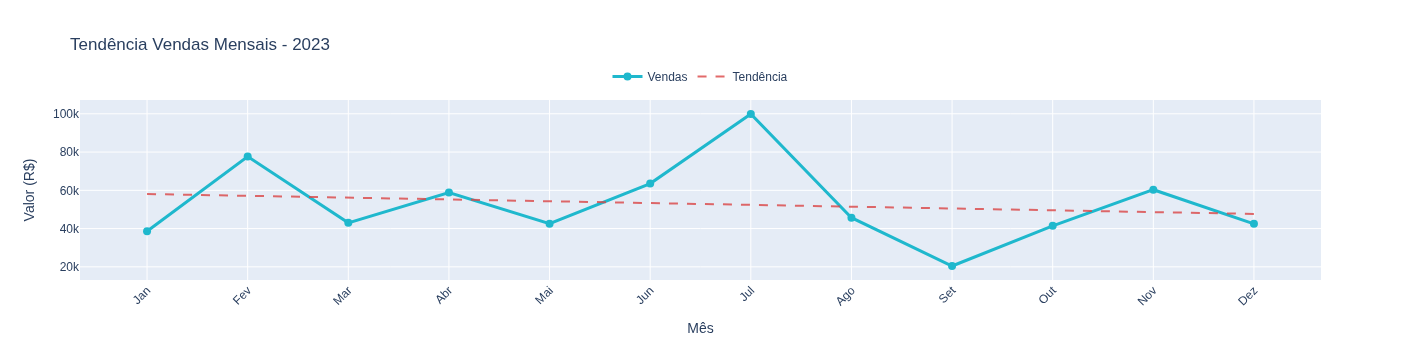

In [11]:
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=vendas_mensais['Mes_Label'],
    y=vendas_mensais['Valor_k'],
    mode='lines+markers',
    name='Vendas',
    line=dict(color='#1FB8CD', width=3),
    marker=dict(size=8, color='#1FB8CD'),
    hovertemplate='%{x}: R$%{y:.1f}k<extra></extra>'
))

x_numeric = np.arange(len(vendas_mensais))
z = np.polyfit(x_numeric, vendas_mensais['Valor_k'], 1)
p = np.poly1d(z)
trend_line = p(x_numeric)

fig.add_trace(go.Scatter(
    x=vendas_mensais['Mes_Label'],
    y=trend_line,
    mode='lines',
    name='Tendência',
    line=dict(color='#DB4545', width=2, dash='dash'),
    opacity=0.8,
    hovertemplate='Tendência: R$%{y:.1f}k<extra></extra>'
))

fig.update_layout(
    title="Tendência Vendas Mensais - 2023",
    xaxis_title="Mês",
    yaxis_title="Valor (R$)",
    legend=dict(orientation='h', yanchor='bottom', y=1.05, xanchor='center', x=0.5),
    showlegend=True
)

fig.update_yaxes(tickformat=".0f", ticksuffix="k")

fig.update_xaxes(tickangle=-45)

fig.update_traces(cliponaxis=False)

* Gráfico de linha mostrando a evolução das vendas mensais durante o ano de 2023

O gráfico de tendência mensal revela uma volatilidade significativa nas vendas ao longo do ano, com picos notáveis em julho (R\$ 99.894) e fevereiro (R\$ 77.692), contrastando com o vale em setembro (R$ 20.444).

In [56]:
print(f"Receita média mensal: R${vendas_mensais['Valor_k'].mean():.1f}k")
print(f"Tendência: {z[0]:.2f}k por mês.")

Receita média mensal: R$52.9k
Tendência: -0.95k por mês.


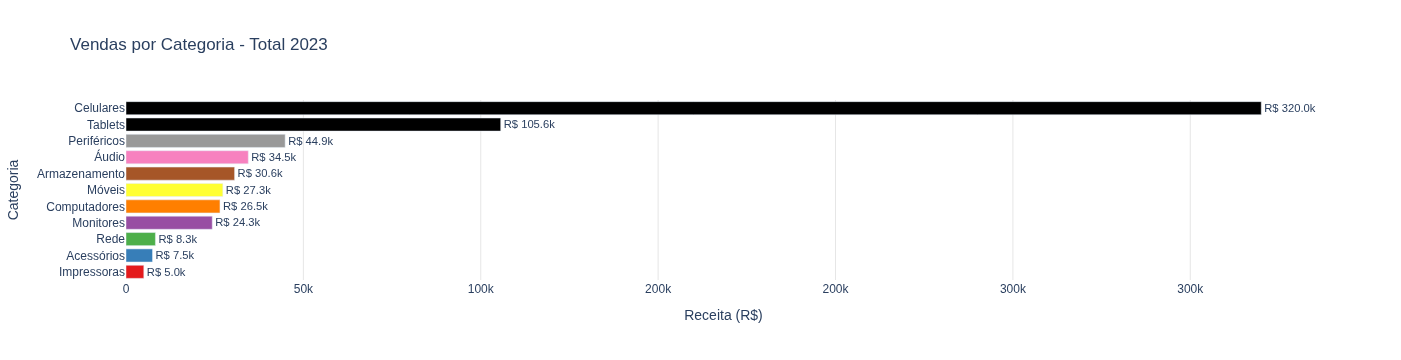

In [12]:

analise_categoria_sorted = analise_categoria.sort_values('Valor', ascending=True)  # ascending=True para barras horizontais coloca o mais alto no topo

fig = go.Figure()

fig.add_trace(go.Bar(
    x=analise_categoria_sorted['Valor'],
    y=analise_categoria_sorted['Categoria'],
    orientation='h',
    text=[f'R$ {val/1000:.1f}k' for val in analise_categoria_sorted['Valor']],
    textposition='outside',
    marker=dict(
        color=px.colors.qualitative.Set1[:len(analise_categoria_sorted)]
    )
))

# Update layout
fig.update_layout(
    title="Vendas por Categoria - Total 2023",
    xaxis_title="Receita (R$)",
    yaxis_title="Categoria",
    showlegend=False,
    xaxis=dict(
        tickformat=',.0f',
        showgrid=True,
        gridcolor='rgba(128,128,128,0.2)',
        gridwidth=1
    ),
    yaxis=dict(
        showgrid=False
    ),
    plot_bgcolor='rgba(0,0,0,0)',
)

fig.update_xaxes(tickformat='.0s')

fig.update_traces(cliponaxis=False)


* Gráfico de barras mostrando a distribuição das vendas por categoria de produtos

A análise por categoria demonstra uma concentração de mercado acentuada, onde Celulares dominam com 50,4% das vendas totais (R\$ 320.003), seguidos por Tablets com 16,7% (R$ 105.616).

In [58]:
print(f"Visualização dos dados:")
print(analise_categoria_sorted[['Categoria', 'Valor']])

Visualização dos dados:
        Categoria       Valor
10    Impressoras    5019.200
9      Acessórios    7470.570
8            Rede    8292.430
7       Monitores   24309.810
6    Computadores   26484.380
5          Móveis   27297.820
4   Armazenamento   30607.845
3           Áudio   34464.170
2     Periféricos   44861.850
1         Tablets  105616.380
0       Celulares  320002.640


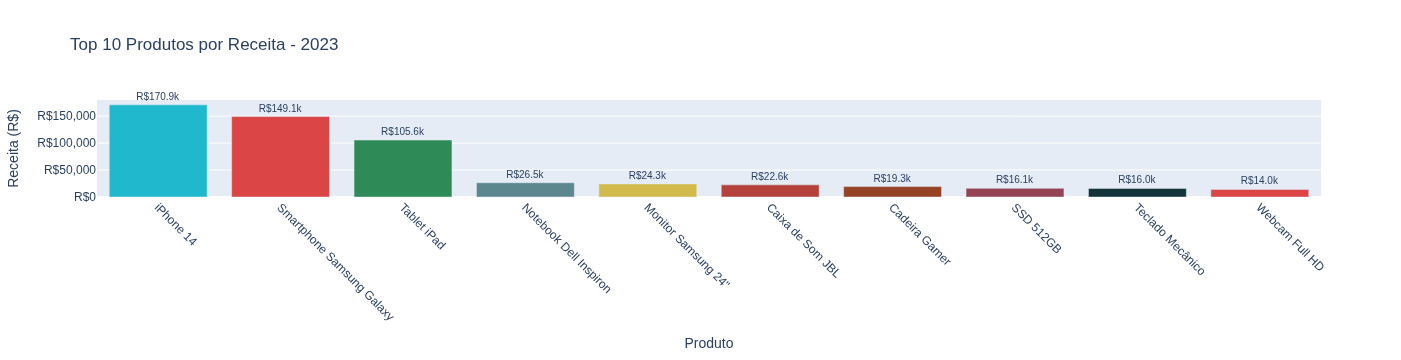

In [13]:
top_10 = analise_produto.head(10).copy()

colors = ['#1FB8CD', '#DB4545', '#2E8B57', '#5D878F', '#D2BA4C',
          '#B4413C', '#964325', '#944454', '#13343B', '#DB4545']

fig = go.Figure(data=[
    go.Bar(
        x=top_10['Produto'],
        y=top_10['Valor'],
        marker_color=colors,
        text=[f'R${val/1000:.1f}k' if val >= 1000 else f'R${val:.0f}' for val in top_10['Valor']],
        textposition='outside',
        textfont=dict(size=10)
    )
])

fig.update_layout(
    title="Top 10 Produtos por Receita - 2023",
    xaxis_title="Produto",
    yaxis_title="Receita (R$)",
    showlegend=False
)

fig.update_xaxes(tickangle=45)

fig.update_yaxes(tickformat=',.0f', tickprefix='R$')

fig.update_traces(cliponaxis=False)

* Gráfico dos 10 produtos com maior receita total em vendas

Entre os produtos individuais, o iPhone 14 lidera com R$ 170.896 em vendas, seguido pelo Samsung Galaxy com R\$ 149.107, evidenciando o domínio dos smartphones premium no portfólio.

In [60]:
# Análises mais detalhadas e identificação de padrões
print("=== ANÁLISE APROFUNDADA E IDENTIFICAÇÃO DE PADRÕES ===")

# 1. Análise sazonal e padrões temporais
print("\n1. PADRÕES TEMPORAIS:")

# Análise por trimestre
vendas_limpo['Trimestre'] = vendas_limpo['Data'].dt.quarter
vendas_trimestrais = vendas_limpo.groupby('Trimestre').agg({
    'Valor': 'sum',
    'Quantidade': 'sum',
    'ID': 'count'
}).reset_index()
print("\nVendas por trimestre:")
print(vendas_trimestrais)

# Identificar tendência de crescimento/decrescimento
vendas_mensais_sorted = vendas_mensais.sort_values('Ano_Mes')
diferenca_mes_anterior = vendas_mensais_sorted['Valor'].pct_change() * 100
print("\nVariação percentual mês a mês (%):")
for i, (_, row) in enumerate(vendas_mensais_sorted.iterrows()):
    if i > 0:
        print(f"{row['Ano_Mes']}: {diferenca_mes_anterior.iloc[i]:.1f}%")


=== ANÁLISE APROFUNDADA E IDENTIFICAÇÃO DE PADRÕES ===

1. PADRÕES TEMPORAIS:

Vendas por trimestre:
   Trimestre       Valor  Quantidade  ID
0          1  159303.480       197.0  77
1          2  164852.705       183.0  73
2          3  166017.970       170.0  62
3          4  144252.940       204.0  83

Variação percentual mês a mês (%):
2023-02: 101.2%
2023-03: -44.6%
2023-04: 36.7%
2023-05: -27.7%
2023-06: 49.4%
2023-07: 57.3%
2023-08: -54.3%
2023-09: -55.2%
2023-10: 102.7%
2023-11: 45.6%
2023-12: -29.6%


In [71]:
# 2. Análise de distribuição de preços e ticket médio
print("\n2. ANÁLISE DE TICKET MÉDIO E DISTRIBUIÇÃO:")

ticket_medio_mensal = vendas_mensais_sorted.copy()
ticket_medio_mensal['Ticket_Medio'] = ticket_medio_mensal['Valor'] / ticket_medio_mensal['Num_Transações']

print("Ticket médio por mês:")
for _, row in ticket_medio_mensal.iterrows():
    print(f"{row['Ano_Mes']}: R$ {row['Ticket_Medio']:.2f}")


2. ANÁLISE DE TICKET MÉDIO E DISTRIBUIÇÃO:
Ticket médio por mês:
2023-01: R$ 1429.85
2023-02: R$ 2506.18
2023-03: R$ 2263.46
2023-04: R$ 3675.42
2023-05: R$ 1371.66
2023-06: R$ 2443.25
2023-07: R$ 3995.76
2023-08: R$ 1756.91
2023-09: R$ 1858.58
2023-10: R$ 1480.03
2023-11: R$ 3015.98
2023-12: R$ 1214.07


In [73]:
# 3. Análise de concentração de vendas
print("\n3. ANÁLISE DE CONCENTRAÇÃO:")

# Por categoria
total_receita = vendas_limpo['Valor'].sum()
concentracao_categoria = analise_categoria.copy()
concentracao_categoria['Percentual'] = (concentracao_categoria['Valor'] / total_receita * 100).round(2)
concentracao_categoria = concentracao_categoria.sort_values('Valor', ascending=False)

print("Concentração por categoria (Top 5):")
print(concentracao_categoria.head()[['Categoria', 'Valor', 'Percentual']])

# Por produto
concentracao_produto = analise_produto.copy()
concentracao_produto['Percentual'] = (concentracao_produto['Valor'] / total_receita * 100).round(2)
print(f"\nTop 5 produtos representam {concentracao_produto.head()['Percentual'].sum():.1f}% das vendas")


3. ANÁLISE DE CONCENTRAÇÃO:
Concentração por categoria (Top 5):
       Categoria       Valor  Percentual
0      Celulares  320002.640       50.44
1        Tablets  105616.380       16.65
2    Periféricos   44861.850        7.07
3          Áudio   34464.170        5.43
4  Armazenamento   30607.845        4.82

Top 5 produtos representam 75.1% das vendas


In [74]:
# 4. Análise de sazonalidade por categoria
print("\n4. SAZONALIDADE POR CATEGORIA:")
categoria_mensal = vendas_limpo.groupby(['Ano_Mes', 'Categoria'])['Valor'].sum().reset_index()
pivot_categoria = categoria_mensal.pivot(index='Ano_Mes', columns='Categoria', values='Valor').fillna(0)

# Principais categorias por trimestre
print("Receita das principais categorias por trimestre:")
trimestre_categoria = vendas_limpo.groupby(['Trimestre', 'Categoria'])['Valor'].sum().reset_index()
top_categorias = ['Celulares', 'Tablets', 'Periféricos', 'Áudio']
for cat in top_categorias:
    cat_data = trimestre_categoria[trimestre_categoria['Categoria'] == cat]
    if not cat_data.empty:
        print(f"\n{cat}:")
        for _, row in cat_data.iterrows():
            print(f"  Q{int(row['Trimestre'])}: R$ {row['Valor']:,.2f}")


4. SAZONALIDADE POR CATEGORIA:
Receita das principais categorias por trimestre:

Celulares:
  Q1: R$ 98,119.10
  Q2: R$ 62,214.66
  Q3: R$ 77,195.58
  Q4: R$ 82,473.30

Tablets:
  Q1: R$ 12,365.10
  Q2: R$ 54,262.78
  Q3: R$ 33,762.00
  Q4: R$ 5,226.50

Periféricos:
  Q1: R$ 10,594.11
  Q2: R$ 11,082.72
  Q3: R$ 9,268.77
  Q4: R$ 13,916.25

Áudio:
  Q1: R$ 9,731.74
  Q2: R$ 9,699.03
  Q3: R$ 6,928.04
  Q4: R$ 8,105.36


In [75]:
# Criar visualização adicional para complementar a análise
print("=== GERAÇÃO DE DADOS PARA GRÁFICO COMPLEMENTAR ===")
# Preparar dados para gráfico de ticket médio mensal
ticket_medio_data = ticket_medio_mensal[['Ano_Mes_str', 'Ticket_Medio']].copy()
ticket_medio_data.to_csv('ticket_medio_mensal.csv', index=False)

print("Dados de ticket médio mensal:")
ticket_medio_data

=== GERAÇÃO DE DADOS PARA GRÁFICO COMPLEMENTAR ===
Dados de ticket médio mensal:


,Ano_Mes_str,Ticket_Medio
0,2023-01,1429.854815
1,2023-02,2506.184839
2,2023-03,2263.456316
3,2023-04,3675.418125
4,2023-05,1371.660323
5,2023-06,2443.251731
6,2023-07,3995.760800
7,2023-08,1756.908462
8,2023-09,1858.575455
9,2023-10,1480.031071


In [78]:
# Preparar dados trimestre vs categoria (top 4 categorias)
print("\n=== DADOS TRIMESTRAIS POR CATEGORIA ===")
top4_categorias = ['Celulares', 'Tablets', 'Periféricos', 'Áudio']
dados_trimestre_categoria = []

for trimestre in [1, 2, 3, 4]:
    for categoria in top4_categorias:
        receita = vendas_limpo[(vendas_limpo['Trimestre'] == trimestre) &
                          (vendas_limpo['Categoria'] == categoria)]['Valor'].sum()
        dados_trimestre_categoria.append({
            'Trimestre': f'Q{trimestre}',
            'Categoria': categoria,
            'Valor': receita
        })

df_trimestre_categoria = pd.DataFrame(dados_trimestre_categoria)
df_trimestre_categoria.to_csv('receita_trimestre_categoria.csv', index=False)
print("Dados trimestrais por categoria (Top 4):")
df_trimestre_categoria


=== DADOS TRIMESTRAIS POR CATEGORIA ===
Dados trimestrais por categoria (Top 4):


,Trimestre,Categoria,Valor
0,Q1,Celulares,98119.10
1,Q1,Tablets,12365.10
2,Q1,Periféricos,10594.11
3,Q1,Áudio,9731.74
4,Q2,Celulares,62214.66
5,Q2,Tablets,54262.78
6,Q2,Periféricos,11082.72
7,Q2,Áudio,9699.03
8,Q3,Celulares,77195.58
9,Q3,Tablets,33762.00


In [81]:
# Insights e padrões identificados
print("\n=== INSIGHTS E PADRÕES IDENTIFICADOS ===")

insights = []

# Insight 1: Volatilidade mensal
cv_receita = (vendas_mensais['Valor'].std() / vendas_mensais['Valor'].mean()) * 100
insights.append(f"1. ALTA VOLATILIDADE MENSAL: Coeficiente de variação de {cv_receita:.1f}% indica grande fluctuação nas vendas mensais.")

# Insight 2: Concentração de mercado
concentracao_top2 = concentracao_categoria.head(2)['Percentual'].sum()
insights.append(f"2. CONCENTRAÇÃO DE MERCADO: As duas principais categorias (Celulares e Tablets) representam {concentracao_top2:.1f}% das vendas totais.")

# Insight 3: Padrão de ticket médio
ticket_alto_meses = ticket_medio_mensal[ticket_medio_mensal['Ticket_Medio'] > 2500]['Ano_Mes_str'].tolist()
insights.append(f"3. TICKET MÉDIO ELEVADO: Meses com ticket médio >R$2.500: {', '.join(ticket_alto_meses)}, indicando vendas de produtos de maior valor.")

# Insight 4: Sazonalidade por categoria
tablet_q2_dominance = (54262.78 / 105616.38) * 100  # Q2 representa X% das vendas de tablets
insights.append(f"4. SAZONALIDADE TABLETS: Q2 concentra {tablet_q2_dominance:.1f}% das vendas anuais de tablets, sugerindo padrão sazonal específico.")

# Insight 5: Eficiência de vendas
mes_mais_eficiente = ticket_medio_mensal.loc[ticket_medio_mensal['Ticket_Medio'].idxmax()]
insights.append(f"5. EFICIÊNCIA COMERCIAL: {mes_mais_eficiente['Ano_Mes']} foi o mês mais eficiente com ticket médio de R$ {mes_mais_eficiente['Ticket_Medio']:,.2f}.")

for insight in insights:
    print(insight)


=== INSIGHTS E PADRÕES IDENTIFICADOS ===
1. ALTA VOLATILIDADE MENSAL: Coeficiente de variação de 39.4% indica grande fluctuação nas vendas mensais.
2. CONCENTRAÇÃO DE MERCADO: As duas principais categorias (Celulares e Tablets) representam 67.1% das vendas totais.
3. TICKET MÉDIO ELEVADO: Meses com ticket médio >R$2.500: 2023-02, 2023-04, 2023-07, 2023-11, indicando vendas de produtos de maior valor.
4. SAZONALIDADE TABLETS: Q2 concentra 51.4% das vendas anuais de tablets, sugerindo padrão sazonal específico.
5. EFICIÊNCIA COMERCIAL: 2023-07 foi o mês mais eficiente com ticket médio de R$ 3,995.76.


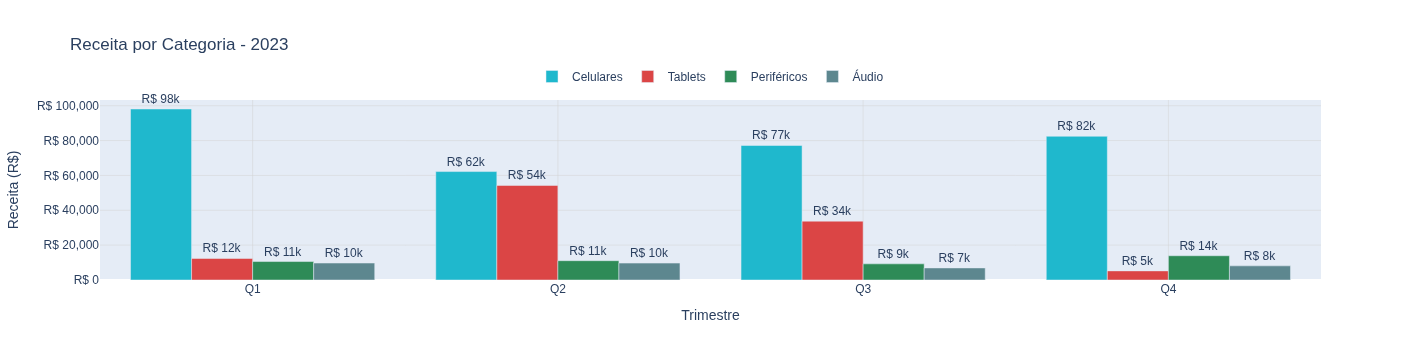

In [15]:
df_receita = pd.read_csv('/home/carlosnogueira/Documentos/Teste_Analytics_CarlosNogueira/data/analysis_results/receita_trimestre_categoria.csv')

colors = ['#1FB8CD', '#DB4545', '#2E8B57', '#5D878F']

fig = go.Figure()

categorias = ['Celulares', 'Tablets', 'Periféricos', 'Áudio']
trimestres = ['Q1', 'Q2', 'Q3', 'Q4']

for i, categoria in enumerate(categorias):
    cat_data = df_receita[df_receita['Categoria'] == categoria]

    receitas = []
    for trimestre in trimestres:
        receita_value = cat_data[cat_data['Trimestre'] == trimestre]['Valor'].values
        receitas.append(receita_value[0] if len(receita_value) > 0 else 0)

    fig.add_trace(go.Bar(
        name=categoria,
        x=trimestres,
        y=receitas,
        marker_color=colors[i],
        text=[f'R$ {val/1000:.0f}k' for val in receitas],
        textposition='outside',
        cliponaxis=False
    ))

fig.update_layout(
    title="Receita por Categoria - 2023",
    xaxis_title="Trimestre",
    yaxis_title="Receita (R$)",
    barmode='group',
    legend=dict(orientation='h', yanchor='bottom', y=1.05, xanchor='center', x=0.5),
    showlegend=True
)

fig.update_yaxes(
    tickformat=',.0f',
    tickprefix='R$ ',
    gridcolor='lightgray',
    gridwidth=0.5
)

fig.update_xaxes(
    gridcolor='lightgray',
    gridwidth=0.5
)


* Gráfico de barras agrupadas mostrando receita trimestral das principais categorias

A análise trimestral por categoria revela padrões sazonais distintos, especialmente para tablets que concentraram 51,4% de suas vendas no Q2, sugerindo influências como volta às aulas ou lançamentos sazonais.

In [85]:
df_receita

,Trimestre,Categoria,Valor
0,Q1,Celulares,98119.10
1,Q1,Tablets,12365.10
2,Q1,Periféricos,10594.11
3,Q1,Áudio,9731.74
4,Q2,Celulares,62214.66
5,Q2,Tablets,54262.78
6,Q2,Periféricos,11082.72
7,Q2,Áudio,9699.03
8,Q3,Celulares,77195.58
9,Q3,Tablets,33762.00


## Principais Insights Identificados
1. Alta Volatilidade Operacional
O coeficiente de variação de 39,4% nas vendas mensais indica flutuações significativas, com variações mês-a-mês chegando a +102,7% (outubro) e -55,2% (setembro). Esta volatilidade sugere dependência de fatores externos como campanhas promocionais ou sazonalidade específica.

2. Concentração de Mercado Extrema
As duas principais categorias (Celulares + Tablets) representam 67,1% do faturamento total, criando alta dependência destes segmentos. Esta concentração representa tanto uma oportunidade de especialização quanto um risco de exposição excessiva.

3. Padrão de Ticket Médio Elevado
Quatro meses apresentaram ticket médio superior a R\$ 2.500 (fevereiro, abril, julho e novembro), coincidindo com períodos de menor volume de transações mas maior valor unitário. O mês mais eficiente foi julho com ticket médio de R\$ 3.996.

4. Sazonalidade Categórica Específica
Tablets demonstram padrão sazonal marcante com 51,4% das vendas anuais concentradas no Q2, enquanto Celulares mantêm distribuição mais equilibrada ao longo dos trimestres. Periféricos mostram leve crescimento no Q4, possivelmente relacionado a compras de final de ano.

5. Eficiência Comercial Variável
A amplitude do ticket médio varia de R\$ 1.214 (dezembro) até R\$ 3.996 (julho), indicando diferentes estratégias comerciais ou mix de produtos vendidos ao longo do ano. Meses de menor ticket coincidiram com maior volume de transações, sugerindo campanhas promocionais.